In [20]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

# Dynamics of fields in a Fabry-Perot cavity

The dynamics are described by the difference equation (Rakhmanov Eq. 1.50):

$E(t) = t_a E_\mathrm{in}(t) + r_a r_b e^{-2 i k d(t)} E(t-2T)$

where:
* $t_a$ is the transmissivity of the input mirror;
* $E_\mathrm{in}(t)$ is input laser field;
* $r_a$ and $r_b$ are the reflectivities of the mirrors (a - input, b - output);
* $k = \omega / c = 2\pi / \lambda$ is the wavenumber;
* $d(t) = L + x_b(t-T) - x_a(t) = L + \xi$ is physical length of the cavity (Rakhmanov Eq. 1.33);
* $T = \frac{L}{c}$ is half of the round-trip time;
* $L$ is half of the round-trip;
* $E(t-2T)$ is .

In [21]:
t_a = 0.1
r_a = 0.9
r_b = 0.9
L = .3  # m
T = L/const.c  # s
E_in = 1  #
lambd = 1064e-9  # m
k = 2*np.pi / lambd

Loss = 1. - np.power(t_a,2) - np.power(r_a,2)
if  Loss < 0.:
    print("Attenti ai valori")
else:
    print("Loss: {0}".format(Loss))

Loss: 0.17999999999999994


In [22]:
def N_eff(r_a, r_b):
    '''
    Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
    '''
    return 1./np.abs(np.log(r_a*r_b))

## Finesse and cavity decay time

$F = \frac{4 r_a r_b}{(1 - r_a r_b)^2}$

$\tau_s = \frac{FL}{c\pi}$

In [23]:
def F():
    return 4.*r_a*r_b / np.power(1.-r_a*r_b, 2)

def tau_s():
    return F() * L / (np.pi * const.c)

In [24]:
print(F())

print(tau_s())

89.75069252077569
2.858831030486214e-08


## Airy function

In [41]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

## Cavity gain

In [68]:
def gain():
    return t_a / (1. - r_a*r_b)

## Cavity parameters summary

In [25]:
N_eff(r_a, r_b)

4.745610790514953

In [26]:
T

1.0006922855944562e-09

In [70]:
gain()

0.5263157894736844

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [60]:
v = 1.e-6/0.01  # m/s

def d(t):
    # Constant
    #return 2

    # Linear    
    c = 1.
    return v*t + c

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [28]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

In [29]:
def S_n(t, n, T):
    '''
    2 S_n is the optical path length for a photon which completed n round trips in the cavity.
    
    t - time
    n - "order" of S function (number of round-trips)
    T - half of the cavity round-trip time
    '''
    S = 0
    for p in np.arange(1, n+1, 1):
        S = S + d(t - 2.*T*p)
    return S

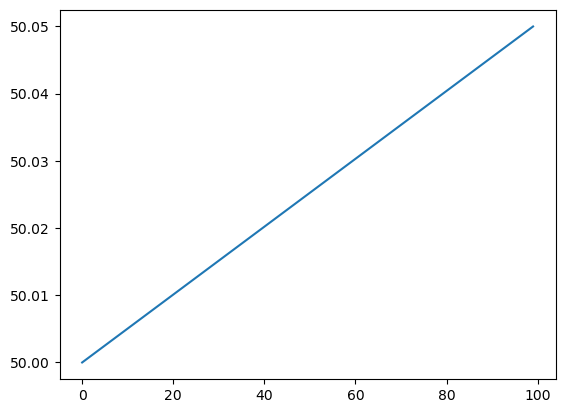

In [30]:
tdata = np.linspace(0,10,100)

res = np.zeros(100)

for idx, t in enumerate(tdata):
    res[idx] = S_n(t, 50, T)
    #print(dat)
#print(y)

plt.plot(res)

In [31]:
def E(t, N=0, recursion_level=0):
    #if t < 0.:
    #    return 0.

    if recursion_level > 500:  # TODO: Verify the accuracy!
        return 0.
    
    if t < -tau_s() * 10:  # 10 times cavity decay time
        return 0.
        
    global t_a, r_a, r_b, T
    
    if N == 0:
        N = N_eff(r_a, r_b) * 10
        #print(N)
    
    if False:
        print("T_a: {0}".format(t_a))
        print("(r_a*r_b)^2: {0}".format(np.power(r_a*r_b, N)))
        print(k*S_n(t, N, T))
        #print(E(t-2.*N*T, N))
        print("--------")

    Sum = 0
    for p in np.arange(1, N+1, 1):
        Sum = Sum + np.power(r_a*r_b, p) * np.exp(-2.j *k*S_n(t, p, T)) * E_in(t-2.*p*T)

    try:
        E_last = E(t - 2.*N*T, N, recursion_level=recursion_level+1)
    except RecursionError:
        print("Recursion lvl: {0}".format(recursion_level))
        E_last = 0.
        
    
    res = t_a * Sum + np.power(r_a*r_b, N) * np.exp(-2.j *k*S_n(t, N, T)) * E_last
    #print("Res: {0}".format(res))
    return res

In [ ]:
E(0.01)

In [32]:
number_of_points = 100

tdata = np.linspace(0., .01, number_of_points)

res = np.zeros(number_of_points)

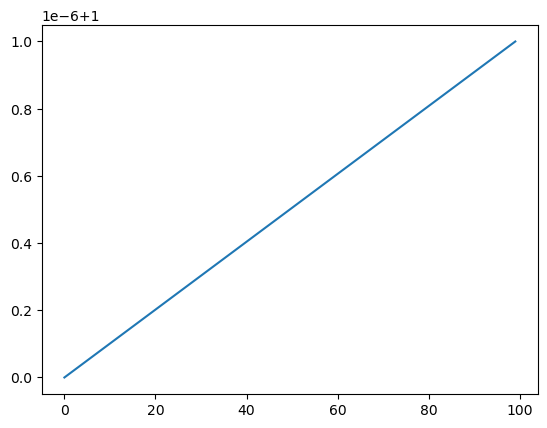

In [33]:
plt.plot(d(tdata))

In [39]:
for idx, t in enumerate(tdata):
    res[idx] = np.abs(E(t, N=3))**2
    #print(dat)
#print(y)

In [131]:
Adata = Airy(F(), (tdata+0.0013)*k*v)

Text(0.5, 0, 'Time [s]')

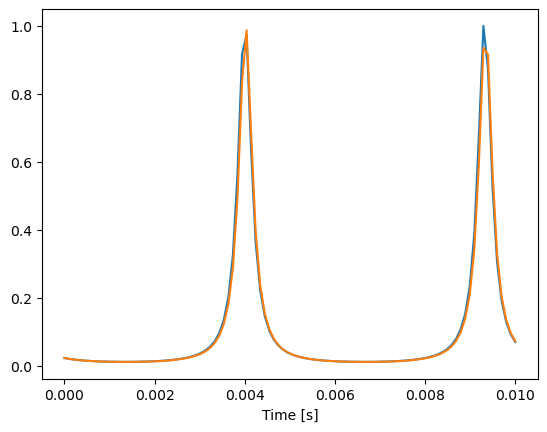

In [136]:
#plt.plot(tdata, res/gain())
plt.plot(tdata, res/np.max(res))
plt.plot(tdata, Adata)
plt.xlabel("Time [s]")

In [134]:
def E_in_large_N_limit(t):
    E = t_a * 
    return E

SyntaxError: invalid syntax (109900060.py, line 2)